# =============================== # Modelling Notebook # ===============================

## Objectives

- Fit and evaluate regression models to predict SalePrice.
- Apply feature engineering pipeline developed earlier.
- Compare candidate regression models using cross-validation.
- Select best model and optimise hyperparameters.
- Export final train/test sets, pipelines, and feature importance plot.


## Inputs 
- outputs/datasets/processed/TrainSet.csv
- outputs/datasets/processed/TestSet.csv

## Outputs
- Train set (features and target)
- Test set (features and target)
- Modeling pipeline
- Feature importance plot

### Import Cell

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Pipelines
from sklearn.pipeline import Pipeline


from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor

# Hyperparameter Search
from sklearn.model_selection import GridSearchCV

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


---

## Change working directory

We need to set the current working directory to the parent folder for consistency.

In [2]:
# Check current directory
current_dir = os.getcwd()
print("Current directory:", current_dir)

# Move to parent directory
os.chdir(os.path.dirname(current_dir))
print("New current directory:", os.getcwd())

Current directory: c:\Users\david\Portfolio 5\heritage-housing\jupyter_notebooks
New current directory: c:\Users\david\Portfolio 5\heritage-housing


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\david\\Portfolio 5\\heritage-housing'

## Load Cleaned Data and Split into Trained and Test Sets



In [4]:
BASE_DIR = Path(r"C:\Users\david\Portfolio 5\heritage-housing")

# Load data
train_path = BASE_DIR / "outputs/datasets/processed/TrainSet.csv"
test_path = BASE_DIR / "outputs/datasets/processed/TestSet.csv"

TrainSet = pd.read_csv(train_path)
TestSet = pd.read_csv(test_path)

target = "SalePrice"

X_train = TrainSet.drop(columns=[target])
y_train = TrainSet[target]

X_test = TestSet.drop(columns=[target])
y_test = TestSet[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1168, 30)
Test shape: (292, 30)


---

## Helper Functions

These functions help check missing values and generate diagnostic plots for numeric and categorical features.

In [5]:
def evaluate_regression (x, y, pipeline):
    """
    Evaluates a trained regression model using common performance metrics.
    """
    y_pred = pipeline.predict(x)

    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

    return mae, rmse, r2

def plot_predictions(x, y, pipeline):
    """
    Plots actual vs predicted values for regression model evaluation.
    """
    y_pred = pipeline.predict(x)

    plt.figure(figsize=(6,6))
    plt.scatter(y, y_pred)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual vs Predicted")
    plt.show()

def plot_residuals(x, y, pipeline):
    """
    Plots residuals (errors) of a regression model to assess model fit.
    Residuals are calculated as: actual - predicted.
    """
    y_pred = pipeline.predict(x)
    residuals = y - y_pred

    plt.figure(figsize=(6,4))
    sns.histplot(residuals, kde= True)
    plt.xlabel("Residuals (Actual - Predicted)")
    plt.title("Residual Distribution")
    plt.show()

def save_model_outputs(model, file_path):
    """
    Saves a trained machine learning pipeline to a specified directory.
    """

    os.makedirs(file_path, exist_ok=True)

    joblib.dump(model, f"{file_path}/model.pkl")

    print(f"Model successfully saved to: {file_path}")

# ===============================
## Model Pipeline
# ===============================

### Model Benchmarking

#### Define Candidate Models

In [6]:
models_quick_search = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42)
}

### Define Hyperparameter Grids (Baseline)

In [7]:
params_quick_search = {
    "LinearRegression": {},
    "Ridge": {},
    "Lasso": {},
    "RandomForestRegressor": {},
    "GradientBoostingRegressor": {},
    "ExtraTreesRegressor": {},
    "XGBRegressor": {}
}

### Run GridSearchCV (Quick Benchmark)

#### Custom class for Hyperparameter Optimization

In [8]:
def PipelineReg(model):
    """
    Create a regression pipeline with scaling, feature selection, and the given model.
    """
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("feat_selection", SelectFromModel(model)),
        ("model", model),
    ])
    return pipeline


class HyperparameterOptimizationSearch:
    """
    Run GridSearchCV across multiple models and summarize cross-validation results.
    """
    def __init__(self, models, params):
        """
        Initialize with model dictionary and corresponding parameter grids.
        """
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, x, y, cv, n_jobs, verbose=1, scoring=None):
        """
        Fit GridSearchCV pipelines for all models using the given CV and scoring settings.
        """
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key}\n")

            model = PipelineReg(self.models[key])
            params = self.params[key]

            gs = GridSearchCV(
                estimator=model,
                param_grid=params,
                cv=cv,
                n_jobs=n_jobs,
                verbose=verbose,
                scoring=scoring
            )

            gs.fit(x, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        """
        Return a dataframe summarizing CV scores for all searched models, sorted by a chosen metric.
        """

        def row(key, scores, params):
            """
            Build a summary row of score statistics and hyperparameters for one estimator run.
            """
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []

            for i in range(self.grid_searches[k].cv):
                key = f"split{i}_test_score"
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))

            all_scores = np.hstack(scores)

            for p, s in zip(params, all_scores):
                rows.append(row(k, s, p))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)

        columns = ['estimator', 'min_score', 'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]

        return df[columns], self.grid_searches

In [9]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='object')


In [10]:
search = HyperparameterOptimizationSearch(
    models=models_quick_search,
    params=params_quick_search
)

search.fit(
    X_train,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)


Running GridSearchCV for LinearRegression

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for Ridge

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for Lasso

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.344e+09, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.344e+09, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(



Running GridSearchCV for RandomForestRegressor

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingRegressor

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesRegressor

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for XGBRegressor

Fitting 5 folds for each of 1 candidates, totalling 5 fits


### Evaluate Model Performance

In [11]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')

grid_search_summary

,estimator,min_score,mean_score,max_score,std_score
4,GradientBoostingRegressor,-23198.373271,-21007.339918,-18875.348845,1741.276318
3,RandomForestRegressor,-24629.738226,-21326.009354,-18973.036738,2128.121429
2,Lasso,-24105.986735,-21971.710865,-20237.648381,1441.511813
5,ExtraTreesRegressor,-24603.123611,-22295.876948,-20084.545107,1548.986757
1,Ridge,-25415.642876,-23065.884404,-20572.199669,1714.768219
6,XGBRegressor,-28262.936427,-24461.834945,-21418.593515,2600.712741
0,LinearRegression,-49229.24563,-47249.666175,-43573.372707,1940.562318


#### Model Selection for Hyperparameter Optimisation

Based on baseline model evaluation using cross-validation, GradientBoostingRegressor achieved the best performance (lowest MAE and good stability across folds).

Therefore, it is selected as the final model for hyperparameter tuning.

### Select Best Performing Model

In [12]:
best_model = grid_search_summary.iloc[0, 0]
best_model

'GradientBoostingRegressor'

### Define Hyperparameter Grid for Best Model

In [13]:
models_search = {
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42)
}

params_search = {
    "GradientBoostingRegressor": {
        "model__n_estimators": [100, 300],
        "model__learning_rate": [0.1, 0.01, 0.001],
        "model__max_depth": [3, 5, 10]
    }
}

### Run GridSearchCV (Tuned Model)

In [14]:
search = HyperparameterOptimizationSearch(
    models=models_search,
    params=params_search
)

search.fit(
    X_train,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)


Running GridSearchCV for GradientBoostingRegressor

Fitting 5 folds for each of 18 candidates, totalling 90 fits


### Evaluate Tuned Model Performance

In [15]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')

grid_search_summary

,estimator,min_score,mean_score,max_score,std_score,model__learning_rate,model__max_depth,model__n_estimators
0,GradientBoostingRegressor,-23198.373271,-21007.339918,-18875.348845,1741.276318,0.1,3,100
2,GradientBoostingRegressor,-24412.638794,-21278.68424,-17960.99532,2069.934618,0.1,5,100
1,GradientBoostingRegressor,-22934.78754,-21303.961352,-18832.048174,1559.28567,0.1,3,300
9,GradientBoostingRegressor,-24286.131151,-21524.67676,-19520.46082,1809.335153,0.01,5,300
3,GradientBoostingRegressor,-24592.440166,-21628.18093,-18492.081053,1938.483855,0.1,5,300
7,GradientBoostingRegressor,-25163.016749,-22574.982913,-20240.990111,2080.360715,0.01,3,300
4,GradientBoostingRegressor,-26732.803779,-24434.554733,-23238.546857,1231.525603,0.1,10,100
5,GradientBoostingRegressor,-26749.731064,-24441.214277,-23252.315027,1236.310152,0.1,10,300
11,GradientBoostingRegressor,-26653.001049,-24591.076472,-23346.404733,1109.180216,0.01,10,300
8,GradientBoostingRegressor,-33579.783203,-30029.875206,-27838.174522,2138.301569,0.01,5,100


### Extract Best Model Pipeline

In [16]:
best_model_name = grid_search_summary.iloc[0, 0]
pipeline_reg = grid_search_pipelines[best_model_name].best_estimator_
best_params = grid_search_pipelines[best_model_name].best_params_

pipeline_reg


Pipeline(steps=[('scaler', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=GradientBoostingRegressor(random_state=42))),
                ('model', GradientBoostingRegressor(random_state=42))])

## Model Evaluation 

### Evaluate Model on Train Set

In [17]:
evaluate_regression(X_train, y_train, pipeline_reg)

MAE: 14957.894538981616
RMSE: 20272.04768153568
R2: 0.9311002689161176


(14957.894538981616, 20272.04768153568, 0.9311002689161176)

### Evaluate Model on Test Set


In [18]:
evaluate_regression(X_test, y_test, pipeline_reg)

MAE: 21702.620233479312
RMSE: 37466.361058645874
R2: 0.81699237124211


(21702.620233479312, 37466.361058645874, 0.81699237124211)

#### Model Train Set vs Test Set comparison 
The model achieves strong performance (R²: 0.93 train, 0.82 test) with mild overfitting. Test MAE (~£21.7k) indicates reasonable prediction error, with higher errors likely occurring on extreme property values.

---

### Plot Actual vs Predicted Values

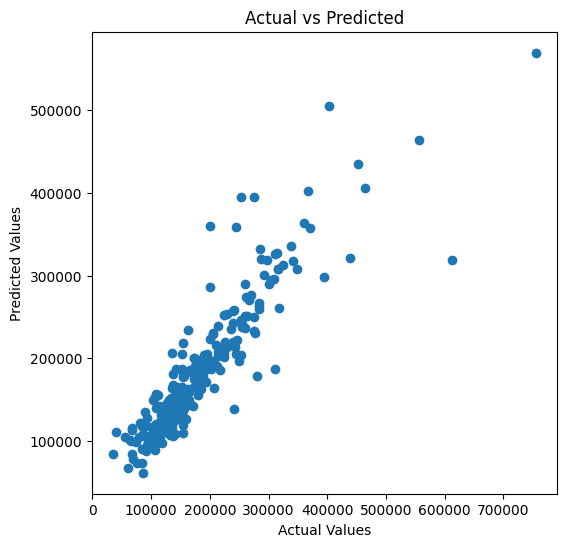

In [19]:
plot_predictions(X_test, y_test, pipeline_reg)

### Plot Residual Distribution

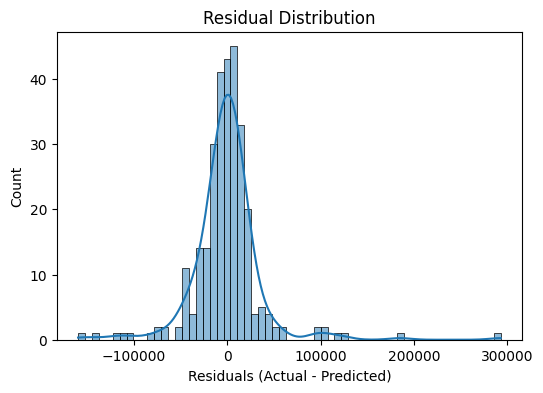

In [20]:
plot_residuals(X_test, y_test, pipeline_reg)

#### Model Fit: Actual vs Predicted Analysis

The model demonstrates a strong overall fit, with predictions generally tracking actual values. However, error variance increases with property value, and the model has larger and more frequent deviations for high-priced properties, indicating reduced reliability on extreme values.

## Feature Importance (Benchmark Pipeline)

### Extract Feature Importance from the Model

In [21]:
model = pipeline_reg.named_steps["model"]
mask = pipeline_reg.named_steps["feat_selection"].get_support()
selected_features = X_train.columns[mask]

df_feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

### Plot Feature Importance

---

<Figure size 1200x600 with 0 Axes>

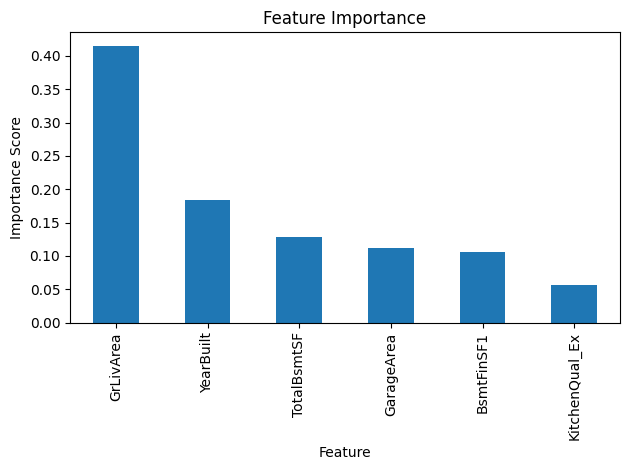

In [22]:
plt.figure(figsize=(12, 6))
df_feature_importance.plot(kind="bar", x="Feature", y="Importance", legend=False)
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

#### Feature Importance Summary

GrLivArea is clearly the dominant predictor, followed by YearBuilt, with TotalBsmtSF, GarageArea, and BsmtFinSF1 contributing moderately. KitchenQual_Ex has minimal impact, indicating the model is driven mainly by size and construction features.




### Final Production Pipeline

#### Define Feature Groups

In [23]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

#### Preprocessing Pipeline

In [24]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#### Final Pipeline Model 

This pipeline uses a ColumnTransformer to apply scaling to numerical features and one-hot encoding to categorical features. This approach ensures preprocessing is performed consistently during both training and inference, improving deployment reliability and reproducibility.

In [25]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
    random_state=42,
    learning_rate=best_params["model__learning_rate"],
    max_depth=best_params["model__max_depth"],
    n_estimators=best_params["model__n_estimators"]
    ))
])

#### Fit Properly and Evaluate

In [26]:
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['BedroomAbvGr', 'BsmtFinSF1', 'BsmtUnfSF', 'GarageArea', 'GrLivArea',
       'LotArea', 'LotFrontage', 'MasVnrArea', 'OpenPorchSF', 'OverallCond',
       'TotalBsmtSF', 'YearBuilt', 'BsmtExposure_No', 'BsmtExposure_Av',
       'BsmtExposure_Gd', 'BsmtExposure_Mn', 'BsmtExposure_Missing',
       'Bsm...Type1_LwQ',
       'BsmtFinType1_BLQ', 'BsmtFinType1_Missing', 'BsmtFinType1_GLQ',
       'GarageFinish_RFn', 'GarageFinish_Missing', 'GarageFinish_Unf',
       'GarageFinish_Fin', 'KitchenQual_TA', 'KitchenQual_Ex',
       'KitchenQual_Fa'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [27]:
evaluate_regression(X_test, y_test, final_pipeline)

MAE: 18135.699387709337
RMSE: 32338.041817908263
R2: 0.8636630411315607


(18135.699387709337, 32338.041817908263, 0.8636630411315607)

### Push Files to Repo

#### Create Export Directory

In [28]:
version = "v1_gb_final"
file_path = BASE_DIR / f"outputs/ml_pipeline/predict_saleprice/{version}"
os.makedirs(file_path, exist_ok=True)

#### Export Data Sets

In [29]:
X_train.to_csv(file_path / "X_train.csv", index=False)
y_train.to_csv(file_path / "y_train.csv", index=False)

X_test.to_csv(file_path / "X_test.csv", index=False)
y_test.to_csv(file_path / "y_test.csv", index=False)

#### Export Trained Model Pipeline

In [30]:
# Export Trained Model Pipeline
joblib.dump(final_pipeline, file_path / "model_pipeline.pkl")

# Export feature list used for training
joblib.dump(X_train.columns.tolist(), file_path / "feature_list.pkl")

['C:\\Users\\david\\Portfolio 5\\heritage-housing\\outputs\\ml_pipeline\\predict_saleprice\\v1_gb_final\\feature_list.pkl']

#### Export Feature Importance Data and Plot

In [31]:
df_feature_importance.to_csv(file_path / "feature_importance.csv", index=False)

<Figure size 1200x600 with 0 Axes>

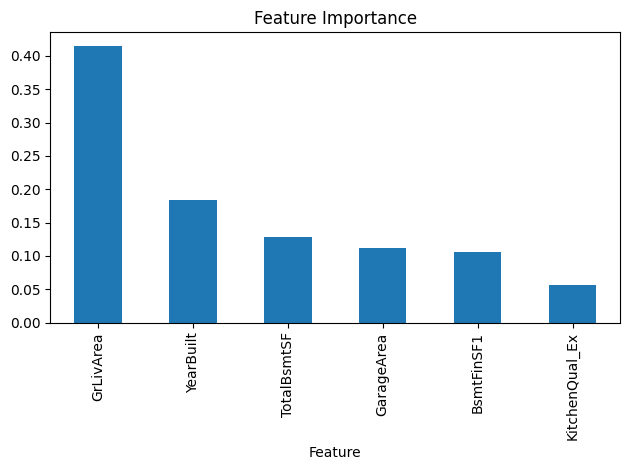

In [32]:
plt.figure(figsize=(12,6))
df_feature_importance.plot(kind="bar", x="Feature", y="Importance", legend=False)
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig(file_path / "feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()

### Final Model Summary

- Model: GradientBoostingRegressor
- CV MAE: 21007.34
- Test MAE: 21,702.62
- Test R²: 0.817
- Top predictors: GrLivArea, YearBuilt, TotalBsmtSF, GarageArea